# Pretrained baselines with SAM — ResNet18, ViT‑B/16
- Fine‑tuning + SAM (ρ≈0.05), LLRD for ViT head, recall‑first evaluation.

In [4]:
# Clean imports + path setup
import sys
from pathlib import Path
import warnings

# tqdm: prefer notebook widgets, fallback to text
try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)

# Resolve project root (directory containing `src/`)
proj_root = Path.cwd()
for _ in range(5):
    if (proj_root / "src").exists():
        break
    proj_root = proj_root.parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))
print("sys.path[0] =", sys.path[0])

# Weights path
weights_path = proj_root / "notebooks" / "weights" / "ViT-B_16.npz"
print("weights:", weights_path)

# Project imports
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch, build_vit_pretrained,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch, time
set_seed(42)
DEVICE = get_device(); DEVICE


sys.path[0] = /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project
weights: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project/notebooks/weights/ViT-B_16.npz


device(type='mps')

In [ ]:
# === Paths/config ===
DATASET_DIR = Path("../Data/chest_xray")  # <--- EDIT THIS IF NEEDED

# Use the SAME split as scratch for fairness
data_cfg = DataCfg(
    dataset_dir=DATASET_DIR,
    image_size=224,
    batch_size=32,
    num_workers=0,
    pin_memory=True,
    use_stratified_val=True,
    val_ratio=0.20,          # <<-- keep this identical across all notebooks
    gray_to_rgb=True,
    compute_norm_stats=False,
    balance_sampler=True     # match whatever you used in scratch
)

pretrain_sam_cfg = TrainCfg(
    epochs=20, patience=5, monitor="va_auroc",
    base_lr=1e-4, weight_decay=1e-4,  # good defaults for pretrained fine-tuning
    clip_grad_norm=1.0, use_amp=False,
    use_sam=True, sam_rho=0.05,      # SAM OFF in this notebook
    use_cosine=True, warmup_epochs=2, min_lr_mult=0.05,
    target_recall=0.95,
    llrd=True, head_lr_mult=10.0,     # faster head for ViT
    vit_npz_path=weights_path         # set this to notebooks/weights/ViT-B_16.npz or None if using timm
)

train_loader, val_loader, test_loader, info = build_dataloaders(data_cfg, DEVICE)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
arr = np.array(info["train_counts"], dtype=float)
w = arr.sum() / (len(arr) * (arr + 1e-9))
class_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4447 785 624


[ResNet18-pretrained+SAM] epoch 01/20  tr_loss=0.6408  val_loss=0.5932  val_acc=0.6752  val_f1=0.7555  val_auroc=0.7705  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 02/20  tr_loss=0.5874  val_loss=0.4993  val_acc=0.7618  val_f1=0.8183  val_auroc=0.8973  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 03/20  tr_loss=0.5354  val_loss=0.4467  val_acc=0.8229  val_f1=0.8692  val_auroc=0.9302  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 04/20  tr_loss=0.4942  val_loss=0.4079  val_acc=0.8484  val_f1=0.8907  val_auroc=0.9425  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 05/20  tr_loss=0.4595  val_loss=0.3674  val_acc=0.8459  val_f1=0.8877  val_auroc=0.9522  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 06/20  tr_loss=0.4320  val_loss=0.3584  val_acc=0.8306  val_f1=0.8737  val_auroc=0.9569  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 07/20  tr_loss=0.4094  val_loss=0.3347  val_acc=0.8573  val_f1=0.8969  val_auroc=0.9528  (no_improve=1)
[ResNet18-pretrained+SAM] epoch 08/20  tr_loss=0

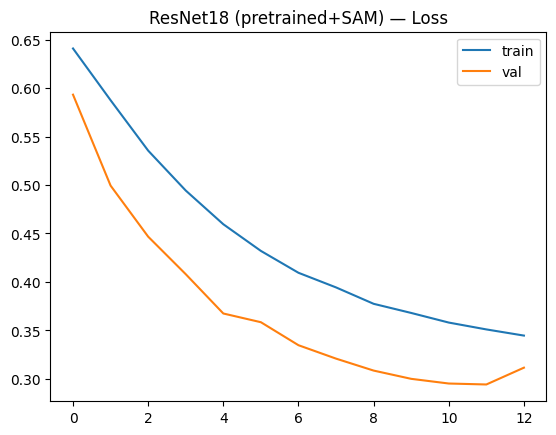

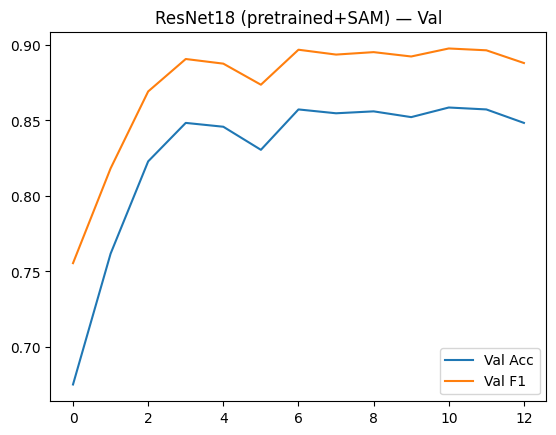

[ResNet18-pretrained+SAM @0.5] {'acc': 0.8285, 'precision': 0.8638, 'recall': 0.8615, 'f1': 0.8626, 'auroc': 0.8943, 'thr': 0.5}
[ResNet18-pretrained+SAM @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.8943, 'thr': 0.0154}


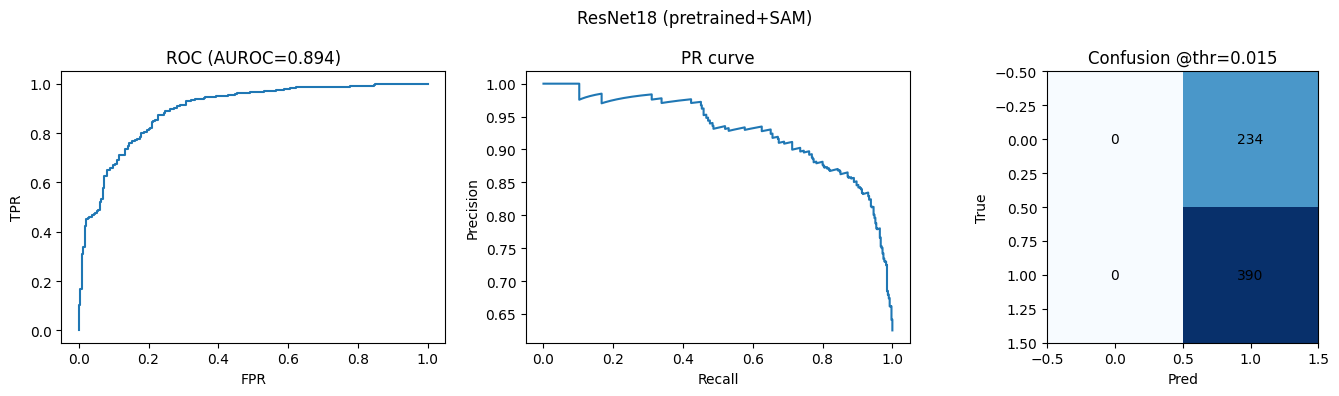

{'summary@0.5': {'acc': 0.8285256410256411,
  'precision': 0.8637532133676092,
  'recall': 0.8615384615384616,
  'f1': 0.8626444159178434,
  'auroc': 0.8943129520052597,
  'thr': 0.5},
 'summary@recall': {'acc': 0.625,
  'precision': 0.625,
  'recall': 1.0,
  'f1': 0.7692307692307693,
  'auroc': 0.8943129520052597,
  'thr': 0.015412816777825356},
 'threshold': 0.015412816777825356,
 'time_sec': 1120.728495836258,
 'params': 11177538}

In [ ]:
import time
from src import (
    build_resnet18, train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots, add_result
)

cfg = pretrain_sam_cfg  # reuse

rn = build_resnet18(in_chans=3, num_classes=2, pretrained=True, conv_stem=False)

t0 = time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=cfg.epochs, base_lr=cfg.base_lr, weight_decay=cfg.weight_decay, label_smoothing=0.0,
    use_sam=True, sam_rho=0.05,                  # SAM rho for ResNet-18 (pretrained)
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="ResNet18-pretrained+SAM"
)
rn_time = time.time() - t0

plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 (pretrained+SAM) — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 (pretrained+SAM) — Val")

va = evaluate(rn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-pretrained+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-pretrained+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (pretrained+SAM)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (pretrained+SAM)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-B/16-pretrained+SAM] epoch 01/20  tr_loss=0.5424  val_loss=0.2593  val_acc=0.8854  val_f1=0.9174  val_auroc=0.9703  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 02/20  tr_loss=0.4243  val_loss=0.4059  val_acc=0.7669  val_f1=0.8142  val_auroc=0.9687  (no_improve=1)
[ViT-B/16-pretrained+SAM] epoch 03/20  tr_loss=0.4040  val_loss=0.2560  val_acc=0.8854  val_f1=0.9177  val_auroc=0.9699  (no_improve=2)
[ViT-B/16-pretrained+SAM] epoch 04/20  tr_loss=0.3732  val_loss=0.2401  val_acc=0.8879  val_f1=0.9196  val_auroc=0.9730  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 05/20  tr_loss=0.3433  val_loss=0.2376  val_acc=0.8790  val_f1=0.9121  val_auroc=0.9778  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 06/20  tr_loss=0.3267  val_loss=0.2137  val_acc=0.9006  val_f1=0.9293  val_auroc=0.9762  (no_improve=1)
[ViT-B/16-pretrained+SAM] epoch 07/20  tr_loss=0.3140  val_loss=0.2038  val_acc=0.8943  val_f1=0.9242  val_auroc=0.9793  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 08/20  tr_loss=0

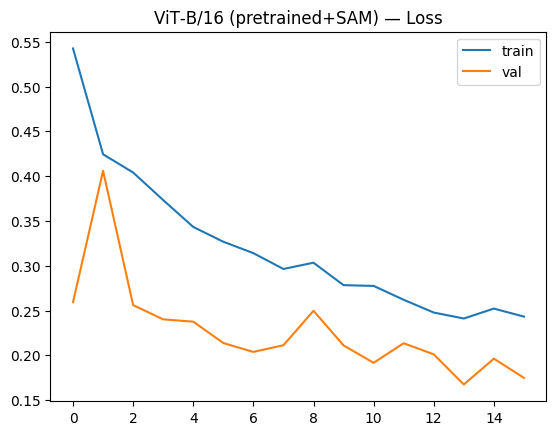

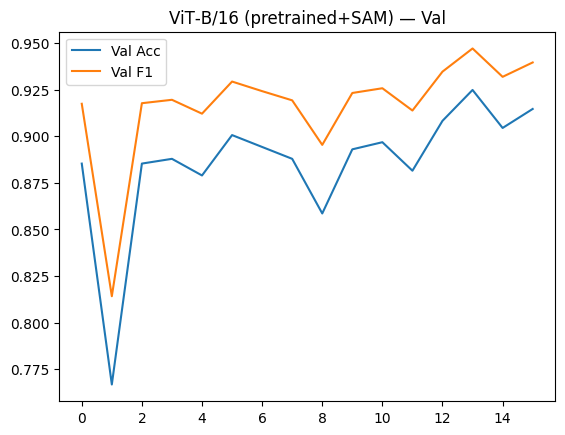

[ViT-B/16-pretrained+SAM @0.5] {'acc': 0.883, 'precision': 0.9054, 'recall': 0.9077, 'f1': 0.9065, 'auroc': 0.9282, 'thr': 0.5}
[ViT-B/16-pretrained+SAM @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.9282, 'thr': 0.0025}


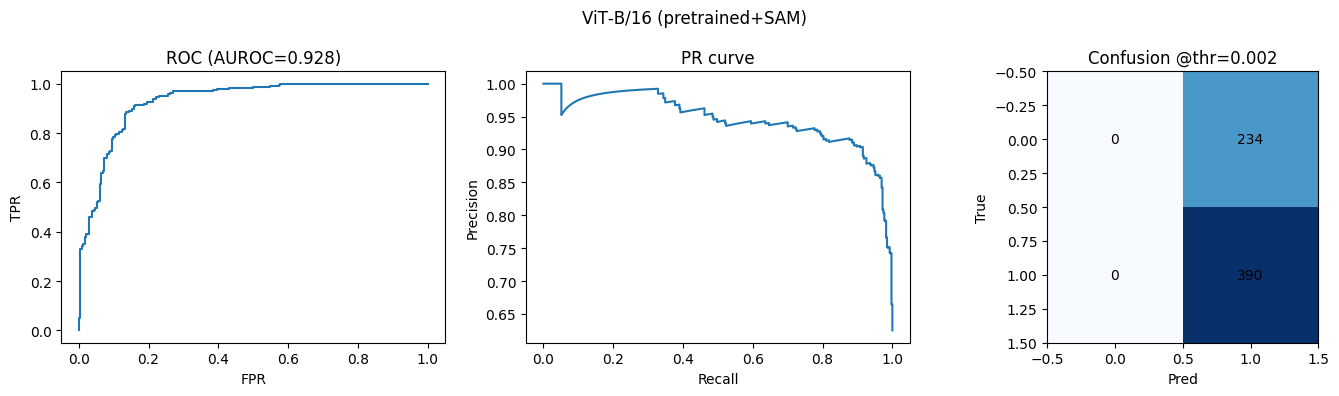

In [ ]:
import time
from src import build_vit_pretrained

# Try TIMM first; fall back to .npz if needed (handled inside build_vit_pretrained)
try:
    vit = build_vit_pretrained(num_classes=2, model_name="vit_base_patch16_224",
                               pretrained=True, npz_path=pretrain_sam_cfg.vit_npz_path)
except Exception as e:
    print("ViT‑B/16 pretrained unavailable (no timm and no .npz). Skipping ViT cell.")
    vit = None

if vit is not None:
    t0 = time.time()
    vit_tr, vit_hist, vit_time = train_model(
        vit, train_loader, val_loader, DEVICE, arch="vit",
        epochs=pretrain_sam_cfg.epochs, base_lr=pretrain_sam_cfg.base_lr, weight_decay=pretrain_sam_cfg.weight_decay, label_smoothing=0.0,
        use_sam=True, sam_rho=0.2,                        # SAM rho for ViT-B/16 (pretrained)
        use_cosine=pretrain_sam_cfg.use_cosine, warmup_epochs=pretrain_sam_cfg.warmup_epochs, min_lr_mult=pretrain_sam_cfg.min_lr_mult,
        monitor=pretrain_sam_cfg.monitor, patience=pretrain_sam_cfg.patience, clip_grad_norm=pretrain_sam_cfg.clip_grad_norm,
        class_weights=class_weights, llrd=pretrain_sam_cfg.llrd, head_lr_mult=pretrain_sam_cfg.head_lr_mult, use_amp=pretrain_sam_cfg.use_amp,
        tag="ViT-B/16-pretrained+SAM"
    )
    vit_time = time.time() - t0

    plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT‑B/16 (pretrained+SAM) — Loss")
    plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT‑B/16 (pretrained+SAM) — Val")

    va = evaluate(vit_tr, val_loader, DEVICE)
    thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], pretrain_sam_cfg.target_recall)
    te = evaluate(vit_tr, test_loader, DEVICE)
    sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
    sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
    print("[ViT-B/16-pretrained+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
    print("[ViT-B/16-pretrained+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
    diag_plots("ViT‑B/16 (pretrained+SAM)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
    add_result("ViT‑B/16 (pretrained+SAM)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [8]:
import pandas as pd
from src import result_registry as RR
rows=[]
for name,d in RR.items():
    s=d.get("summary@recall", d.get("summary@0.5")); 
    if not s: continue
    thr=d.get("threshold", s.get("thr",0.5))
    rows.append({"Model":name,"Params (M)": round(d.get("params",0)/1e6,2) if d.get("params") else None,
                 "Time (min)": round(d.get("time_sec",0)/60,2) if d.get("time_sec") else None,
                 "Acc":round(s["acc"],4),"Prec":round(s["precision"],4),"Recall":round(s["recall"],4),
                 "F1":round(s["f1"],4),"AUROC":round(s.get("auroc",float('nan')),4),"Thr":round(thr,3)})
df=pd.DataFrame(rows).sort_values(by=["F1","AUROC"], ascending=False).reset_index(drop=True)
display(df); print(df.to_string(index=False))


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,ViT‑B/16 (pretrained+SAM),85.80,106.33,0.625,0.625,1.0,0.7692,0.9282,0.002
1,ResNet18 (pretrained+SAM),11.18,18.68,0.625,0.625,1.0,0.7692,0.8943,0.015


                    Model  Params (M)  Time (min)   Acc  Prec  Recall     F1  AUROC   Thr
ViT‑B/16 (pretrained+SAM)       85.80      106.33 0.625 0.625     1.0 0.7692 0.9282 0.002
ResNet18 (pretrained+SAM)       11.18       18.68 0.625 0.625     1.0 0.7692 0.8943 0.015
